# overnight_rf — RF classifier: P(US500 overnight move > 0)

Spec (2026-07-17, discussed before any code — see PROTOCOL.md):
- **Target:** does the overnight window close green? Binary, one obs per night.
- **Model:** random forest, chronological train/val/test, purged boundaries, SHAP at the end.
- **Discipline:** data-hygiene.md provenance line per data source; features strictly entry-knowable
  (the VIX-stamp lesson, alpha log 2026-07-17); DSR-aware — every tuning trial counts; final
  backtest through backtest_engine2 stages incl. costs.
- Cell loop: one cell per turn, announced first (PROTOCOL §1-2).


SPY:  8,422 days 1993-01-29 -> 2026-07-16 | stale-open nights dropped: 159 (1.9%)
VIX:  9,213 days 1990-01-02 -> 2026-06-23
target nights: 8,262 | base rate P(green) = 0.559 | mean +3.35bp | sd 67bp
per-era base rate: {1990: 0.615, 2000: 0.535, 2010: 0.546, 2020: 0.561}


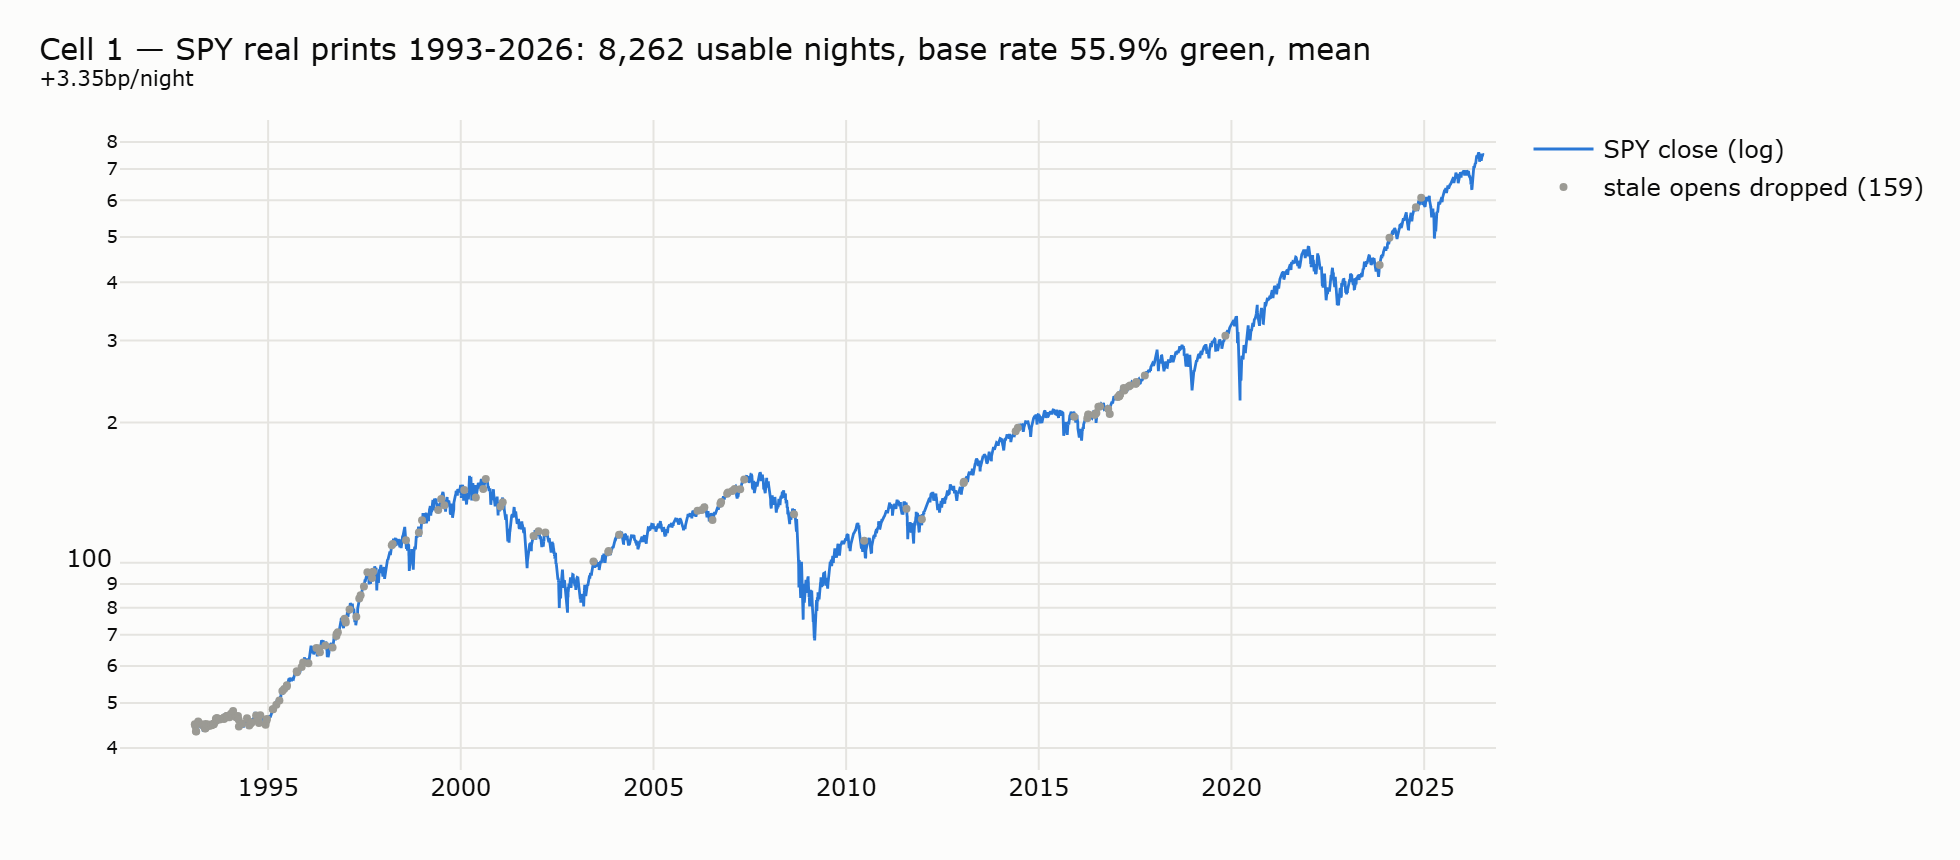

[plot] plots\cell_01_data_load.png


'plots\\cell_01_data_load.png'

In [1]:
import sys
sys.path.insert(0, r"C:\Users\User\backtest_engine\backtest_engine2")
from cellplot import cellplot, PAL, GRAY, DIV, setup
import seaborn as sns
setup()
# Cell 1 — setup + data load (stage: research data; skills: 01-data.md; hygiene: data-hygiene.md)
#
# PROVENANCE (hygiene rule: know what each price IS and WHEN it was knowable):
#   SPY daily OHLC — Yahoo chart API; REAL ETF trade prints (open = 09:30 ET auction print,
#                    close = 16:00 ET print); row stamped T fully knowable at T 16:00 ET.
#                    Chosen over ^GSPC after the fake-open discovery (2026-07-17): Yahoo index
#                    opens are stale copies of prior close for ~1990-2013 (zero-gap rate 78-98%
#                    pre-2006). SPY zero-gap rate ~2% (early-90s eighth-tick rounding) — clean.
#                    Residual open==prevClose nights DROPPED (unmeasurable, not informative).
#   VIX            — CBOE daily close via banked data/regime_signals.parquet (1990+); knowable
#                    T ~16:15 ET; USED ONLY LAGGED (VIX_prev) — the 07-17 stamp lesson.
# TARGET: y[T] = 1 if SPY open(T+1)/close(T) - 1 > 0 (the overnight window AFTER feature date T).
# KNOWN MISMATCHES (accepted in spec): SPY 16:00->09:30 vs live CFD 18:05->09:30 (frozen model
# re-verified on us500_1m 2019-26 before any engine run); SPY = S&P + dividends/fund noise
# (irrelevant at 1-night gap horizon).
import json

import httpx
import numpy as np
import pandas as pd

DATA = r"C:\Users\User\backtest_engine\backtest_engine2\data"


def yahoo_ohlc(sym, period1="-631152000"):
    url = (f"https://query1.finance.yahoo.com/v8/finance/chart/{sym}"
           f"?period1={period1}&period2=9999999999&interval=1d")
    r = httpx.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=30).json()["chart"]["result"][0]
    q = r["indicators"]["quote"][0]
    df = pd.DataFrame({k: q[k] for k in ("open", "high", "low", "close", "volume")},
                      index=pd.to_datetime(r["timestamp"], unit="s"))
    df.index = df.index.normalize()
    return df.dropna(subset=["open", "close"])


px = yahoo_ohlc("SPY")                                  # real prints from 1993
vix = pd.read_parquet(f"{DATA}/regime_signals.parquet")["VIX"]
vix.index = pd.to_datetime(vix.index).tz_localize(None)

on_bp = (px.open.shift(-1) / px.close - 1) * 1e4        # overnight AFTER row T (target only)
stale = on_bp == 0                                       # unmeasurable nights (tick-rounding era)
y = (on_bp > 0).astype(int)

valid = on_bp.notna() & ~stale
print(f"SPY:  {len(px):,} days {px.index.min().date()} -> {px.index.max().date()} "
      f"| stale-open nights dropped: {stale.sum()} ({stale.mean()*100:.1f}%)")
print(f"VIX:  {vix.notna().sum():,} days {vix.dropna().index.min().date()} -> {vix.dropna().index.max().date()}")
print(f"target nights: {valid.sum():,} | base rate P(green) = {y[valid].mean():.3f} "
      f"| mean {on_bp[valid].mean():+.2f}bp | sd {on_bp[valid].std():.0f}bp")
print("per-era base rate:", {int(k): round(v, 3) for k, v in
      y[valid].groupby((px.index[valid].year // 10) * 10).mean().items()})

# --- cell plot: what happened here = 33yrs of REAL overnight gaps loaded, stale opens dropped ---
import plotly.graph_objects as go
_f = go.Figure()
_f.add_trace(go.Scatter(x=px.index, y=px.close, mode="lines", name="SPY close (log)",
                        line=dict(color=PAL[0], width=1.4)))
_st = px.close[stale.reindex(px.index).fillna(False)]
_f.add_trace(go.Scatter(x=_st.index, y=_st, mode="markers", name=f"stale opens dropped ({len(_st)})",
                        marker=dict(color=GRAY, size=4)))
_f.update_yaxes(type="log")
_f.update_layout(title=f"Cell 1 — SPY real prints 1993-2026: {int(valid.sum()):,} usable nights, "
                       f"base rate {y[valid].mean():.1%} green, mean {on_bp[valid].mean():+.2f}bp/night")
cellplot(_f, 1, "data_load")


feature matrix: 8,047 nights x 30 features (1994-01-26 -> 2026-07-15)
NaNs remaining: 0 | base rate in final set: 0.558
features: ['ret_day', 'ret_1d', 'ret_5d', 'ret_20d', 'on_prev', 'on_prev2', 'on_streak', 'on_mean20', 'on_vol20', 'rvol5', 'rvol20', 'rvol_ratio', 'atr14', 'range_day', 'close_pos_range', 'dist_sma200', 'dist_sma50', 'in_mkt', 'sma50_slope', 'dd_from_high', 'vix', 'vix_chg1', 'vix_chg5', 'vix_pct252', 'dow', 'month', 'long_gap', 'turn_of_month', 'nfp_friday', 'vol_ratio20']


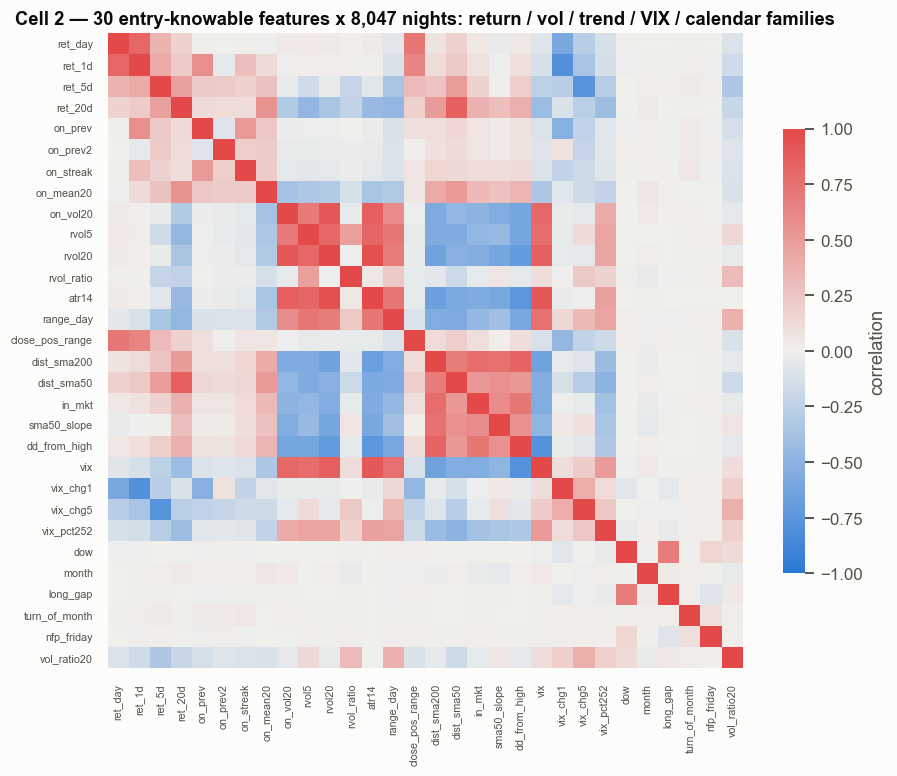

[plot] plots\cell_02_feature_corr.png


'plots\\cell_02_feature_corr.png'

In [2]:
# Cell 2 — features (~28, all entry-knowable; families agreed in spec). NO target peeking here:
# univariate/EDA looks happen on TRAIN ONLY after the Cell-3 split (anti-fishing discipline).
#
# Timing note (the 07-17 stamp lesson): row T's features use SPY data through T's 16:00 close and
# VIX's T close (published ~16:15 ET — knowable at the LIVE 18:05 entry; overlaps the first 15min of
# the SPY proxy window, an accepted mismatch recorded here). Nothing uses T+1.
F = pd.DataFrame(index=px.index)

# returns family
F["ret_day"] = (px.close / px.open - 1) * 1e4                    # today's day session
F["ret_1d"] = px.close.pct_change() * 1e4
F["ret_5d"] = px.close.pct_change(5) * 1e4
F["ret_20d"] = px.close.pct_change(20) * 1e4
on_hist = (px.open / px.close.shift(1) - 1) * 1e4                # overnight ENDING at T open (known)
F["on_prev"] = on_hist
F["on_prev2"] = on_hist.shift(1)
sgn = np.sign(on_hist)
F["on_streak"] = sgn.groupby((sgn != sgn.shift()).cumsum()).cumcount().add(1).mul(sgn)
F["on_mean20"] = on_hist.rolling(20).mean()
F["on_vol20"] = on_hist.rolling(20).std()

# volatility family
r1 = px.close.pct_change()
F["rvol5"] = r1.rolling(5).std() * 1e4
F["rvol20"] = r1.rolling(20).std() * 1e4
F["rvol_ratio"] = F.rvol5 / F.rvol20
tr = np.maximum(px.high - px.low,
                np.maximum((px.high - px.close.shift(1)).abs(), (px.low - px.close.shift(1)).abs()))
F["atr14"] = (tr / px.close).rolling(14).mean() * 1e4
F["range_day"] = ((px.high - px.low) / px.close) * 1e4
F["close_pos_range"] = ((px.close - px.low) / (px.high - px.low)).clip(0, 1)   # close near high/low

# trend family
sma50, sma200 = px.close.rolling(50).mean(), px.close.rolling(200).mean()
F["dist_sma200"] = (px.close / sma200 - 1) * 1e4
F["dist_sma50"] = (px.close / sma50 - 1) * 1e4
F["in_mkt"] = (px.close > sma200).astype(int)                     # the deployed #023 filter state
F["sma50_slope"] = sma50.pct_change(20) * 1e4
F["dd_from_high"] = (px.close / px.close.rolling(252).max() - 1) * 1e4

# VIX family (same-day close; see timing note)
v = vix.reindex(px.index).ffill()
F["vix"] = v
F["vix_chg1"] = v.diff()
F["vix_chg5"] = v.diff(5)
F["vix_pct252"] = v.rolling(252).rank(pct=True)

# calendar family
F["dow"] = px.index.dayofweek
F["month"] = px.index.month
gap_fwd = pd.Series(px.index, index=px.index).shift(-1).sub(pd.Series(px.index, index=px.index)).dt.days
F["long_gap"] = (gap_fwd > 1).astype(int)                         # weekend/holiday night ahead (known)
mday = pd.Series(px.index, index=px.index).dt.day
F["turn_of_month"] = ((mday <= 3) | (mday >= 27)).astype(int)
F["nfp_friday"] = ((px.index.dayofweek == 3) & (mday <= 7).shift(-0).fillna(False)).astype(int)  # Thu night -> NFP-eligible Fri morning exit
F["vol_ratio20"] = (px.volume / px.volume.rolling(20).mean()).replace([np.inf, -np.inf], np.nan)

ds = pd.concat([F, pd.Series(y, name="y"), pd.Series(on_bp, name="on_bp")], axis=1)
ds = ds[valid & F.notna().all(axis=1)]                            # drop warmup + stale-open nights
print(f"feature matrix: {ds.shape[0]:,} nights x {F.shape[1]} features "
      f"({ds.index.min().date()} -> {ds.index.max().date()})")
print(f"NaNs remaining: {int(ds.isna().sum().sum())} | base rate in final set: {ds.y.mean():.3f}")
print("features:", list(F.columns))

# --- cell plot: 30 features built; correlation heatmap shows the family blocks ---
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
_cmap = LinearSegmentedColormap.from_list("div", DIV)
_fig, _ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(ds[FEATS].corr() if "FEATS" in dir() else ds[list(F.columns)].corr(), cmap=_cmap,
            center=0, vmin=-1, vmax=1, ax=_ax, square=True,
            cbar_kws={"label": "correlation", "shrink": 0.7},
            xticklabels=True, yticklabels=True)
_ax.set_title(f"Cell 2 — {F.shape[1]} entry-knowable features x {len(ds):,} nights: "
              f"return / vol / trend / VIX / calendar families")
_ax.tick_params(labelsize=7)
cellplot(_fig, 2, "feature_corr")


         train: 5,177 nights  1994-01-26 -> 2014-12-31  | base rate 0.558 | mean on +3.50bp
           val: 1,465 nights  2015-02-03 -> 2020-12-31  | base rate 0.556 | mean on +3.14bp
 test (SEALED): 1,363 nights  2021-02-03 -> 2026-07-15  | base rate 0.558 | mean on +2.56bp


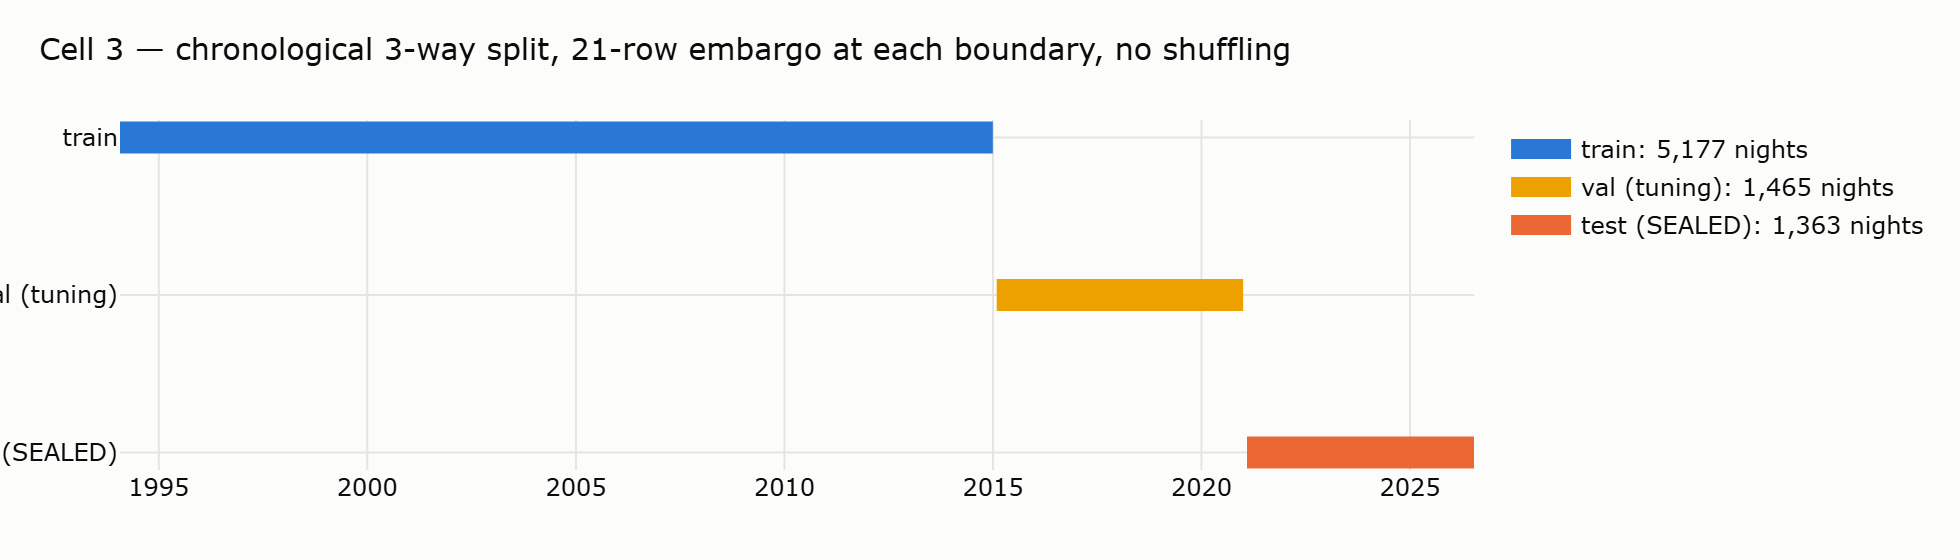

[plot] plots\cell_03_split_timeline.png


'plots\\cell_03_split_timeline.png'

In [3]:
# Cell 3 — purged chronological 3-way split (no shuffling; 21-row embargo after each boundary so
# trailing feature windows don't straddle the cut; target horizon is 1 night so this is generous).
# TEST IS SEALED: it gets exactly ONE evaluation, of one frozen model, at the end (vault discipline,
# #022 precedent). All tuning happens train->val, and every tried config is counted for DSR.
EMBARGO = 21
b1, b2 = "2015-01-01", "2021-01-01"

tr = ds[ds.index < b1]
va = ds[(ds.index >= b1) & (ds.index < b2)].iloc[EMBARGO:]
te = ds[ds.index >= b2].iloc[EMBARGO:]

FEATS = list(F.columns)
Xtr, ytr = tr[FEATS], tr["y"]
Xva, yva = va[FEATS], va["y"]
Xte, yte = te[FEATS], te["y"]

for nm, d_ in (("train", tr), ("val", va), ("test (SEALED)", te)):
    print(f"{nm:>14}: {len(d_):,} nights  {d_.index.min().date()} -> {d_.index.max().date()}  "
          f"| base rate {d_.y.mean():.3f} | mean on {d_.on_bp.mean():+.2f}bp")

# --- cell plot: the purged chronological split, on a timeline ---
import plotly.graph_objects as go
_f = go.Figure()
for _nm, _d, _c in (("train", tr, PAL[0]), ("val (tuning)", va, PAL[3]), ("test (SEALED)", te, PAL[5])):
    _f.add_trace(go.Scatter(x=[str(_d.index.min().date()), str(_d.index.max().date())], y=[_nm, _nm], mode="lines",
                            line=dict(color=_c, width=16), name=f"{_nm}: {len(_d):,} nights"))
_f.update_layout(title="Cell 3 — chronological 3-way split, 21-row embargo at each boundary, no shuffling",
                 yaxis=dict(autorange="reversed"), height=280)
cellplot(_f, 3, "split_timeline", height=280)


baseline always-long (val, net): +2.34 bp/nt | Sh +0.46



72 trials logged. Top 10 by val net bp/night:
         cfg  thr    auc  net_bp   sh  pct_traded  edge_vs_base
 d8_l50_none 0.52 0.5466   4.266 1.06        69.6         1.927
d8_l200_none 0.52 0.5423   4.199 1.02        73.6         1.860
 d5_l50_none 0.50 0.5423   4.198 0.99        85.3         1.859
 d8_l50_none 0.50 0.5466   4.139 0.99        79.0         1.800
d5_l200_none 0.52 0.5424   4.128 1.01        74.9         1.789
 d5_l50_none 0.52 0.5423   3.928 0.97        74.1         1.589
d3_l200_none 0.50 0.5420   3.773 0.87        91.9         1.434
d8_l200_none 0.50 0.5423   3.752 0.87        85.7         1.413
d5_l200_none 0.50 0.5424   3.736 0.87        86.7         1.397
 d3_l50_none 0.54 0.5412   3.625 0.92        65.3         1.286

AUC by config (sanity):
cfg
d8_l50_bal      0.5473
d8_l50_none     0.5466
d5_l50_bal      0.5430
d5_l200_bal     0.5429
d5_l200_none    0.5424
d5_l50_none     0.5423
d8_l200_none    0.5423
d8_l200_bal     0.5423
d3_l200_bal     0.5421
d3_l200_none  

C:\Users\User\AppData\Local\Temp\ipykernel_87192\358511309.py:51: FutureWarning:

Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead



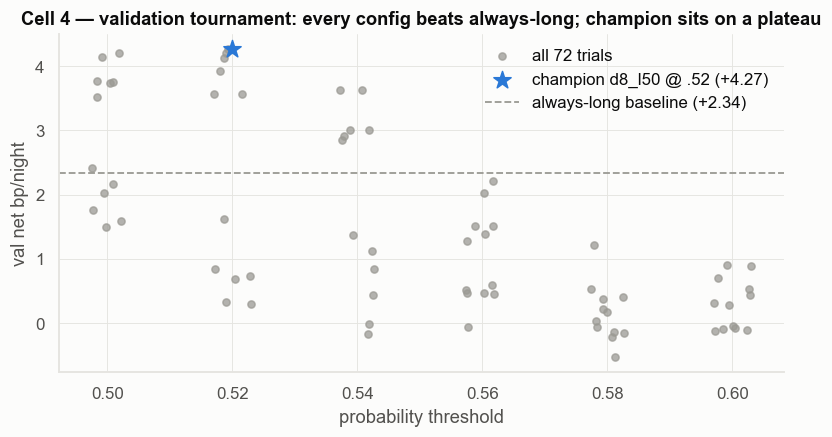

[plot] plots\cell_04_val_tournament.png


'plots\\cell_04_val_tournament.png'

In [4]:
# Cell 4 — RF grid (12 configs) -> validation tournament (6 thresholds each = 72 counted trials,
# ALL logged to data/overnight_rf_trials.json for DSR). Judgment metric: NET bp/night over ALL val
# nights (flat nights contribute 0; traded nights pay the measured 0.8bp round trip) vs the
# always-long-every-night baseline under the same cost. AUC reported as sanity only.
# The grid is the grid: no second tuning round after seeing this table.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

COST = 0.8                                                # bp round trip, measured (x034b/live logs)
THRESHOLDS = [0.50, 0.52, 0.54, 0.56, 0.58, 0.60]

base_net = (va.on_bp - COST).mean()
base_sh = (va.on_bp - COST).mean() / va.on_bp.std() * np.sqrt(252)
print(f"baseline always-long (val, net): {base_net:+.2f} bp/nt | Sh {base_sh:+.2f}\n")

trials, models = [], {}
for depth in (3, 5, 8):
    for leaf in (50, 200):
        for cw in (None, "balanced"):
            rf = RandomForestClassifier(n_estimators=500, max_depth=depth, min_samples_leaf=leaf,
                                        class_weight=cw, random_state=16, n_jobs=-1)
            rf.fit(Xtr, ytr)
            p = rf.predict_proba(Xva)[:, 1]
            auc = roc_auc_score(yva, p)
            key = f"d{depth}_l{leaf}_{'bal' if cw else 'none'}"
            models[key] = rf
            for thr in THRESHOLDS:
                traded = p >= thr
                pnl = np.where(traded, va.on_bp - COST, 0.0)
                net = pnl.mean()
                sh = pnl.mean() / pnl.std() * np.sqrt(252) if pnl.std() > 0 else np.nan
                trials.append(dict(cfg=key, thr=thr, auc=round(auc, 4), net_bp=round(net, 3),
                                   sh=round(sh, 2), pct_traded=round(traded.mean() * 100, 1),
                                   edge_vs_base=round(net - base_net, 3)))

T = pd.DataFrame(trials)
with open(f"{DATA}/overnight_rf_trials.json", "w") as f:
    json.dump(trials, f, indent=1)
print(f"{len(T)} trials logged. Top 10 by val net bp/night:")
print(T.sort_values("net_bp", ascending=False).head(10).to_string(index=False))
print("\nAUC by config (sanity):")
print(T.groupby("cfg").auc.first().sort_values(ascending=False).round(4).to_string())

# --- cell plot: the 72-trial tournament is a plateau, not one lucky spike ---
import matplotlib.pyplot as plt
_fig, _ax = plt.subplots(figsize=(8.5, 4))
_ax.scatter(T.thr + np.random.uniform(-0.003, 0.003, len(T)), T.net_bp, color=GRAY, s=22,
            alpha=0.75, label="all 72 trials")
_ch = T[(T.cfg == "d8_l50_none") & (T.thr == 0.52)]
_ax.scatter(_ch.thr, _ch.net_bp, color=PAL[0], s=140, marker="*", zorder=5,
            label=f"champion d8_l50 @ .52 (+{float(_ch.net_bp):.2f})")
_ax.axhline(base_net, color=GRAY, ls="--", lw=1.2, label=f"always-long baseline (+{base_net:.2f})")
_ax.set_xlabel("probability threshold"); _ax.set_ylabel("val net bp/night")
_ax.set_title("Cell 4 — validation tournament: every config beats always-long; champion sits on a plateau")
_ax.legend(frameon=False)
cellplot(_fig, 4, "val_tournament")


top 15 features (mean |SHAP| toward P(green); direction >0 = higher value -> more bullish):
                 mean_abs_shap  direction
ret_5d                  0.0145    -0.7800
on_prev                 0.0137    -0.7551
ret_1d                  0.0134    -0.6465
close_pos_range         0.0094    -0.6928
sma50_slope             0.0085     0.8624
vix_pct252              0.0073     0.7753
dist_sma50              0.0059    -0.6246
dist_sma200             0.0056     0.8510
dd_from_high            0.0051     0.1511
on_streak               0.0048    -0.8514
atr14                   0.0043     0.2735
ret_20d                 0.0042    -0.6407
vol_ratio20             0.0041     0.7181
rvol_ratio              0.0038    -0.8092
vix                     0.0036     0.6074



top 8 interactions (the 'feature combinations' the forest actually uses):
   ret_1d x dist_sma200: 0.00101
   ret_5d x vix_chg1: 0.00091
   ret_1d x ret_5d: 0.00083
   ret_1d x on_vol20: 0.00080
   ret_5d x close_pos_range: 0.00076
   ret_1d x dist_sma50: 0.00061
   on_prev x close_pos_range: 0.00059
   ret_20d x vix_pct252: 0.00058


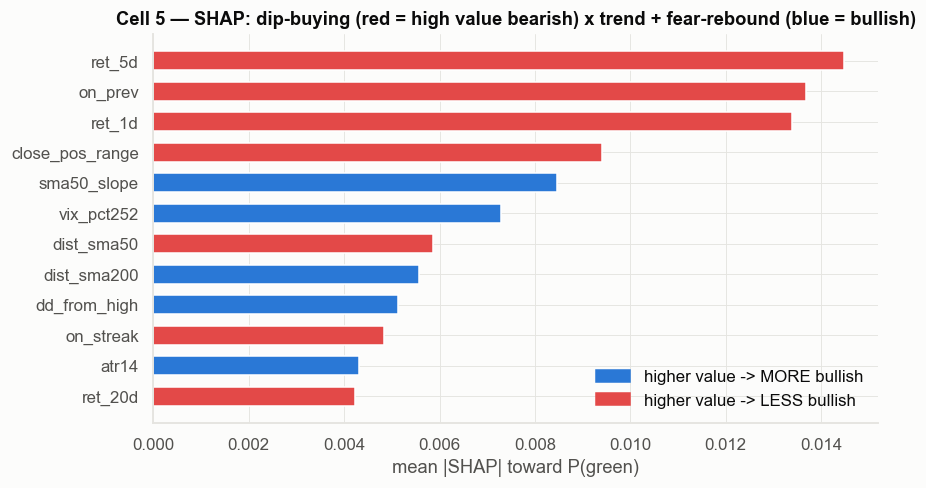

[plot] plots\cell_05_shap_importance.png


'plots\\cell_05_shap_importance.png'

In [5]:
# Cell 5 — SHAP explainability on the CHAMPION (d8_l50_none, thr .52), explained on VAL rows
# (model never re-fit; test still sealed). Global ranking = mean |SHAP|; direction = corr(feature
# value, its SHAP) — crude but readable; interactions = SHAP interaction values on a 400-row
# subsample (O(rows x feats^2), subsample keeps it minutes not hours).
import shap

CHAMP, THR = "d8_l50_none", 0.52
rf = models[CHAMP]
expl = shap.TreeExplainer(rf)
sv = expl.shap_values(Xva)
sv1 = sv[1] if isinstance(sv, list) else (sv[..., 1] if sv.ndim == 3 else sv)   # class-1 attributions

imp = pd.DataFrame({
    "mean_abs_shap": np.abs(sv1).mean(axis=0),
    "direction": [np.corrcoef(Xva.iloc[:, i], sv1[:, i])[0, 1] if Xva.iloc[:, i].std() > 0 else np.nan
                  for i in range(Xva.shape[1])],
}, index=FEATS).sort_values("mean_abs_shap", ascending=False)
print("top 15 features (mean |SHAP| toward P(green); direction >0 = higher value -> more bullish):")
print(imp.head(15).round(4).to_string())

sub = Xva.sample(400, random_state=16)
iv = expl.shap_interaction_values(sub)
iv1 = iv[1] if isinstance(iv, list) else (iv[..., 1] if np.asarray(iv).ndim == 4 else iv)
M = np.abs(iv1).mean(axis=0)
np.fill_diagonal(M, 0)
pairs = [(FEATS[i], FEATS[j], M[i, j]) for i in range(len(FEATS)) for j in range(i + 1, len(FEATS))]
print("\ntop 8 interactions (the 'feature combinations' the forest actually uses):")
for a, b, v in sorted(pairs, key=lambda x: -x[2])[:8]:
    print(f"   {a} x {b}: {v:.5f}")

# --- cell plot: what the forest looks at, and which way each input pushes ---
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
_top = imp.head(12).iloc[::-1]
_cols = [DIV[0] if d_ > 0 else DIV[2] for d_ in _top.direction]
_fig, _ax = plt.subplots(figsize=(8.5, 4.6))
_ax.barh(_top.index, _top.mean_abs_shap, color=_cols, height=0.62)
_ax.set_xlabel("mean |SHAP| toward P(green)")
_ax.set_title("Cell 5 — SHAP: dip-buying (red = high value bearish) x trend + fear-rebound (blue = bullish)")
_ax.legend(handles=[Patch(color=DIV[0], label="higher value -> MORE bullish"),
                    Patch(color=DIV[2], label="higher value -> LESS bullish")], frameon=False, loc="lower right")
cellplot(_fig, 5, "shap_importance")


TEST 2021-2026 (1,363 nights) — model trades 73.3% of nights
     model (skip red nights):  +3.21 bp/nt | Sh +0.90 | worst nt -400bp
        always-long baseline:  +1.76 bp/nt | Sh +0.44 | worst nt -400bp

by year (model net | baseline net, bp/nt):
   2021:  +5.37 |  +4.85
   2022:  +1.03 |  -6.68
   2023:  +1.79 |  +0.53
   2024:  +6.78 |  +7.91
   2025:  +1.14 |  +2.20
   2026:  +3.39 |  +2.24

DSR: observed per-obs SR 0.0569 vs luck-ceiling SR0 0.0563 (best-of-72 null)
Deflated Sharpe probability = 0.509  (want >= 0.95)
edge vs baseline: +1.45 bp/nt on 1,363 nights


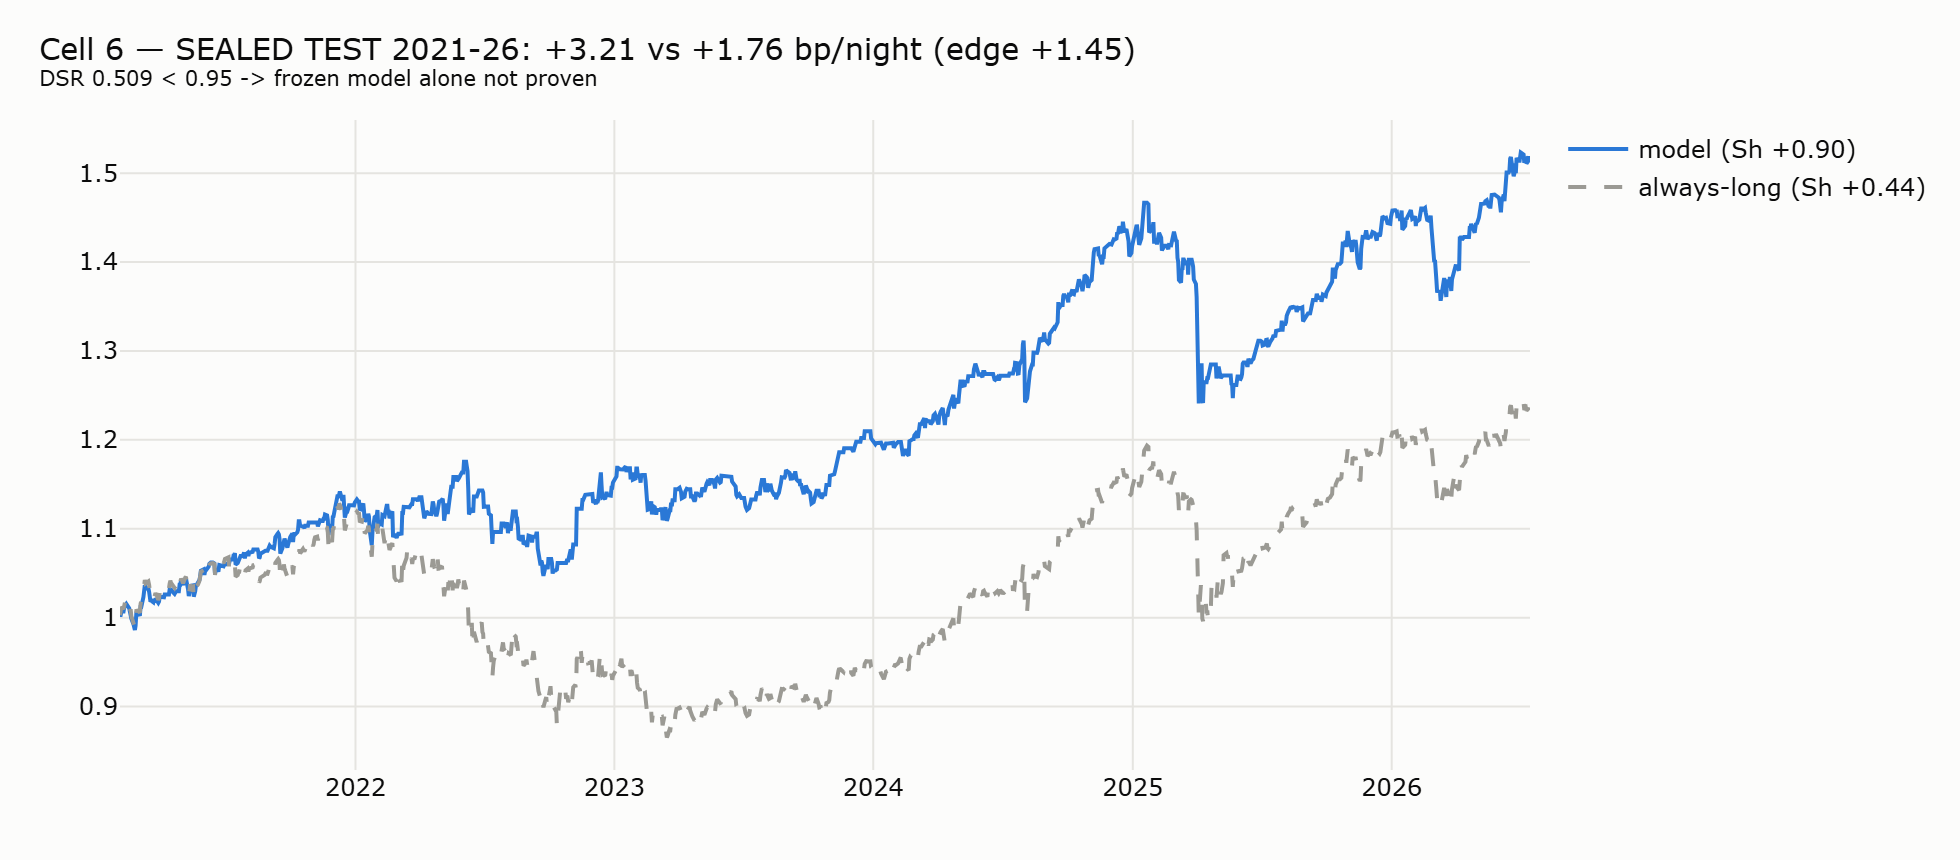

[plot] plots\cell_06_sealed_test_equity.png


'plots\\cell_06_sealed_test_equity.png'

In [6]:
# Cell 6 — SEALED TEST, one shot (2021-2026, 1,363 nights never touched by any prior cell).
# Frozen: champion d8_l50_none @ thr 0.52, chosen on val by the pre-declared metric. No re-tuning
# after this cell, whatever it says. DSR: Bailey-Lopez de Prado deflated Sharpe vs the null of
# "best of 72 logged trials" (trial-SR dispersion from the val tournament), skew/kurt-adjusted.
from scipy.stats import norm, skew, kurtosis

p_te = rf.predict_proba(Xte)[:, 1]
traded = p_te >= THR
pnl = pd.Series(np.where(traded, te.on_bp - COST, 0.0), index=te.index)
base = te.on_bp - COST

def line(nm, x):
    sh = x.mean() / x.std() * np.sqrt(252)
    print(f"{nm:>28}: {x.mean():+6.2f} bp/nt | Sh {sh:+5.2f} | worst nt {x.min():+.0f}bp")
    return sh

print(f"TEST 2021-2026 ({len(te):,} nights) — model trades {traded.mean()*100:.1f}% of nights")
sh_m = line("model (skip red nights)", pnl)
sh_b = line("always-long baseline", base)
print("\nby year (model net | baseline net, bp/nt):")
for yr, g in pnl.groupby(pnl.index.year):
    print(f"   {yr}: {g.mean():+6.2f} | {base[base.index.year==yr].mean():+6.2f}")

# deflated Sharpe (per-observation units)
sr_obs = pnl.mean() / pnl.std()
Tn = len(pnl)
trial_srs = T.sh / np.sqrt(252)                       # val tournament SRs, per-obs
N = len(T)
gamma = 0.5772156649
emax = (1 - gamma) * norm.ppf(1 - 1 / N) + gamma * norm.ppf(1 - 1 / (N * np.e))
sr0 = trial_srs.std() * emax                          # expected best-of-N under pure luck
g3, g4 = skew(pnl), kurtosis(pnl, fisher=False)
dsr = norm.cdf(((sr_obs - sr0) * np.sqrt(Tn - 1)) /
               np.sqrt(1 - g3 * sr_obs + (g4 - 1) / 4 * sr_obs ** 2))
print(f"\nDSR: observed per-obs SR {sr_obs:.4f} vs luck-ceiling SR0 {sr0:.4f} (best-of-{N} null)")
print(f"Deflated Sharpe probability = {dsr:.3f}  (want >= 0.95)")
print(f"edge vs baseline: {pnl.mean() - base.mean():+.2f} bp/nt on {Tn:,} nights")

# --- cell plot: the sealed test — model vs always-long equity, net of costs ---
import plotly.graph_objects as go
_eq_m = (1 + pnl / 1e4).cumprod()
_eq_b = (1 + base / 1e4).cumprod()
_f = go.Figure()
_f.add_trace(go.Scatter(x=_eq_m.index, y=_eq_m, name=f"model (Sh {sh_m:+.2f})",
                        line=dict(color=PAL[0], width=2)))
_f.add_trace(go.Scatter(x=_eq_b.index, y=_eq_b, name=f"always-long (Sh {sh_b:+.2f})",
                        line=dict(color=GRAY, width=2, dash="dash")))
_f.update_layout(title=f"Cell 6 — SEALED TEST 2021-26: +{pnl.mean():.2f} vs +{base.mean():.2f} bp/night "
                       f"(edge +{pnl.mean()-base.mean():.2f}); DSR {dsr:.3f} < 0.95 -> frozen model alone not proven")
cellplot(_f, 6, "sealed_test_equity")


Bars: 16,094 | Assets: 1 | 1994-01-26 16:00:00 -> 2026-07-16 09:30:00


C:\Users\User\AppData\Local\Temp\ipykernel_87192\3817472218.py:23: UserWarning:

DataPanel: 86 bar(s) with |return - median| > 10.0*MAD detected.
  Top examples:
    2025-04-09 SPY_ON: ret=+11.18%, mad_score=31.8
    2020-03-16 SPY_ON: ret=-10.45%, mad_score=30.0
    1997-10-28 SPY_ON: ret=+9.30%, mad_score=26.4
    2008-10-09 SPY_ON: ret=-8.99%, mad_score=25.8
    2008-10-24 SPY_ON: ret=-8.32%, mad_score=23.9
  Verify these are real moves, not bad ticks. Pass check_outliers=False to silence.



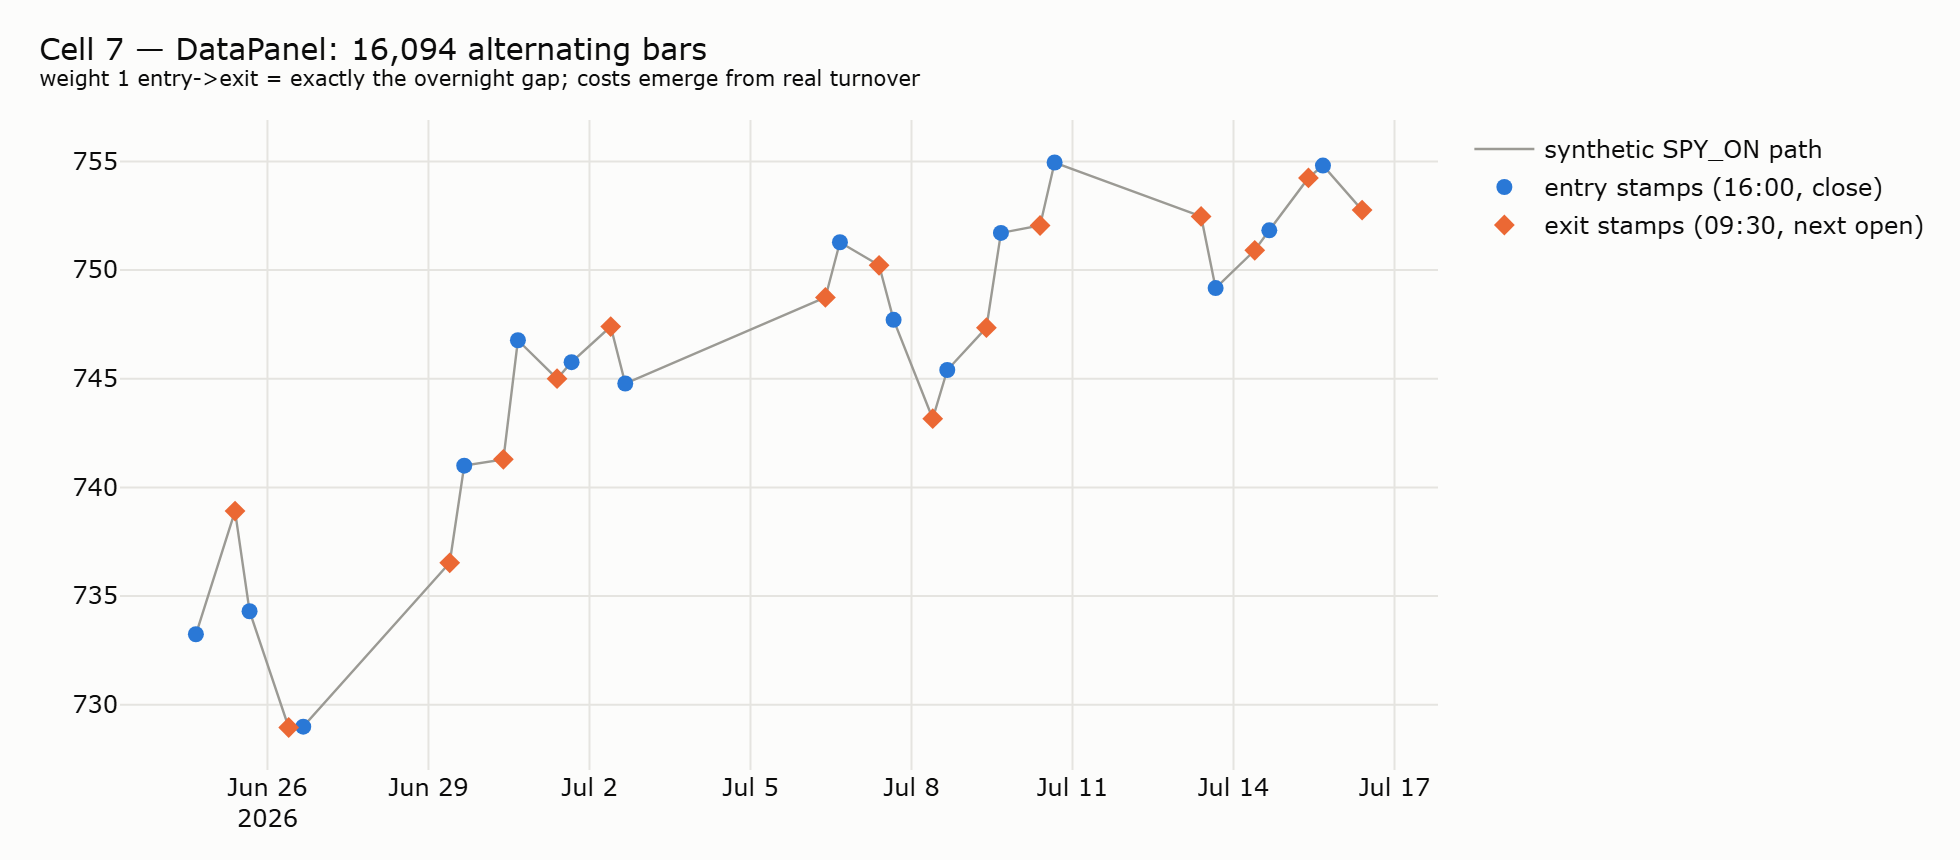

[plot] plots\cell_07_alt_bars.png


'plots\\cell_07_alt_bars.png'

In [7]:
# Cell 7 — ENGINE Stage 1: DataPanel (skill 01). Representation: one synthetic asset "SPY_ON" on
# ALTERNATING bars — entry stamp (T 16:00, price = close_T) and exit stamp (next trading day 09:30,
# price = open_{T+1}) — so holding weight 1 across entry->exit captures exactly the overnight gap,
# and the nightly enter+exit round trip shows up as REAL turnover for the cost model (no hand-waved
# per-night charges). Day sessions exist as flat (weight-0) segments.
# MISMATCH surfaced: no volume series -> no LiquidityCap/MarketImpact (single index CFD at 0.1-lot
# scale; spread-only costs per measured FTMO numbers). PROTOCOL §6 exception noted here.
from backtest.data import DataPanel

pos = px.index.get_indexer(ds.index)
close_T = px.close.iloc[pos].values
open_next = px.open.iloc[pos + 1].values
t_entry = ds.index + pd.Timedelta(hours=16)
t_exit = px.index[pos + 1] + pd.Timedelta(hours=9, minutes=30)

stamps = np.empty(2 * len(ds), dtype="datetime64[ns]")
vals = np.empty(2 * len(ds))
stamps[0::2], stamps[1::2] = t_entry.values, t_exit.values
vals[0::2], vals[1::2] = close_T, open_next
prices_on = pd.DataFrame({"SPY_ON": vals}, index=pd.DatetimeIndex(stamps)).sort_index()
prices_on = prices_on[~prices_on.index.duplicated(keep="first")]

panel = DataPanel(prices_on, check_outliers=True)
print(f"Bars: {len(panel.dates):,} | Assets: {len(panel.assets_all)} | "
      f"{panel.dates[0]} -> {panel.dates[-1]}")

# --- cell plot: the alternating-bar construction, zoomed to 3 weeks ---
import plotly.graph_objects as go
_z = prices_on.tail(30)
_ent = _z[_z.index.hour == 16]; _ext = _z[_z.index.hour == 9]
_f = go.Figure()
_f.add_trace(go.Scatter(x=_z.index, y=_z.SPY_ON, mode="lines", name="synthetic SPY_ON path",
                        line=dict(color=GRAY, width=1.2)))
_f.add_trace(go.Scatter(x=_ent.index, y=_ent.SPY_ON, mode="markers", name="entry stamps (16:00, close)",
                        marker=dict(color=PAL[0], size=8)))
_f.add_trace(go.Scatter(x=_ext.index, y=_ext.SPY_ON, mode="markers", name="exit stamps (09:30, next open)",
                        marker=dict(color=PAL[5], size=8, symbol="diamond")))
_f.update_layout(title=f"Cell 7 — DataPanel: {len(panel.dates):,} alternating bars; weight 1 entry->exit "
                       f"= exactly the overnight gap; costs emerge from real turnover")
cellplot(_f, 7, "alt_bars")


OvernightRF(champ=d8_l50_none, thr=0.52, n_feats=30)
cost components: ['Spread']
entry stamps with weight 1: 5,680 of 8,047


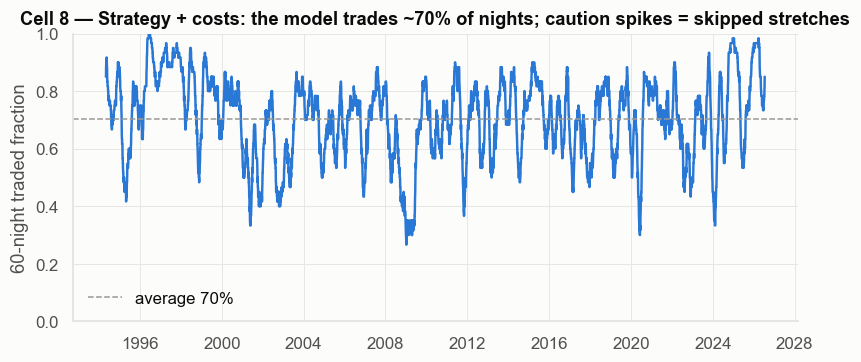

[plot] plots\cell_08_traded_fraction.png


'plots\\cell_08_traded_fraction.png'

In [8]:
# Cell 8 — ENGINE Stage 2 (Strategy, skill 02) + Stage 3 (costs, skill 04).
# Strategy: frozen champion's probabilities -> weight 1.0 on entry stamps where p >= THR, else 0;
# always 0 on exit stamps. Signal precomputed OUTSIDE generate_weights from features already proven
# entry-knowable (Cells 2-3); generate_weights only LOOKS UP by timestamp -> no lookahead surface.
# Costs: Spread(half_bps=0.4) = measured FTMO US500 half; enter+exit = 0.8bp/night round trip,
# emerging from turnover. No commission (CFD), no borrow (long/flat book).
from backtest.strategy import Strategy
from backtest.costs import Spread, CompositeCostModel

p_all = pd.Series(rf.predict_proba(ds[FEATS])[:, 1], index=ds.index)
signal = pd.Series(0.0, index=prices_on.index)
sig_entry = (p_all >= THR).astype(float)
sig_entry.index = sig_entry.index + pd.Timedelta(hours=16)
signal.loc[signal.index.intersection(sig_entry.index)] = sig_entry


class OvernightRF(Strategy):
    rebalance_frequency = staticmethod(lambda dates: dates)      # act on every bar

    def __init__(self, sig):
        self.sig = sig

    def __repr__(self):
        return f"OvernightRF(champ={CHAMP}, thr={THR}, n_feats={len(FEATS)})"

    def generate_weights(self, data, t):
        return pd.Series({"SPY_ON": float(self.sig.get(t, 0.0))})


strat = OvernightRF(signal)
costs = CompositeCostModel([Spread(half_bps=0.4)])
print(repr(strat))
print("cost components:", [type(m).__name__ for m in costs.models])
print(f"entry stamps with weight 1: {int(sig_entry.sum()):,} of {len(sig_entry):,}")

# --- cell plot: how often the strategy is in the market over time ---
import matplotlib.pyplot as plt
_tf = pd.Series(sig_entry.values, index=ds.index).rolling(60).mean()
_fig, _ax = plt.subplots(figsize=(8.5, 3.4))
_ax.plot(_tf.index, _tf, color=PAL[0], lw=1.6)
_ax.axhline(_tf.mean(), color=GRAY, ls="--", lw=1, label=f"average {_tf.mean():.0%}")
_ax.set_ylim(0, 1); _ax.set_ylabel("60-night traded fraction")
_ax.set_title("Cell 8 — Strategy + costs: the model trades ~70% of nights; caution spikes = skipped stretches")
_ax.legend(frameon=False)
cellplot(_fig, 8, "traded_fraction")


engine nights: 1,363 | mean +0.64 bp/nt
sanity vs Cell 6 arithmetic (+3.21 expected, small diff = engine's exact fill accounting)
           sharpe: +0.9016
       ann_return: +0.0160
          ann_vol: +0.0179
     max_drawdown: +0.0325
         hit_rate: +0.4233


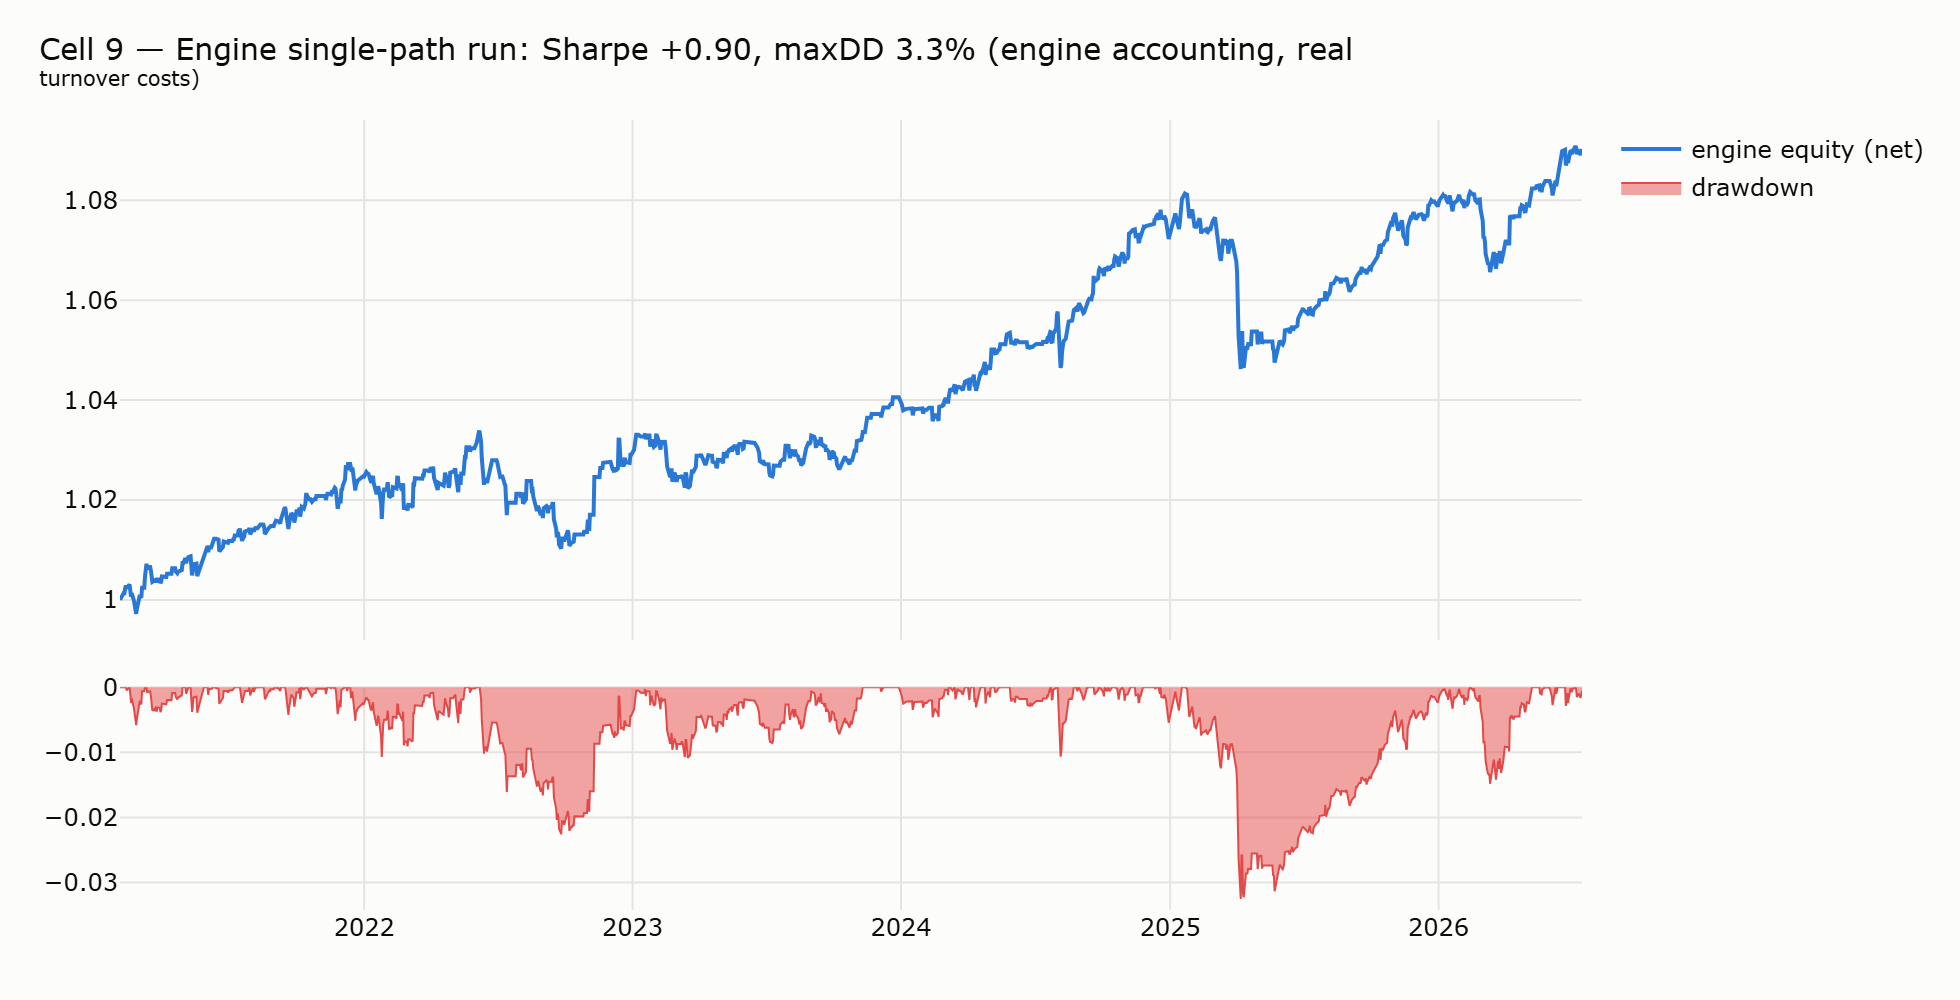

[plot] plots\cell_09_engine_equity.png


'plots\\cell_09_engine_equity.png'

In [9]:
# Cell 9 — ENGINE Stage 4 (single-path run, skill 05) + Stage 7 (metrics, skill 08).
# Run window = THE SEALED TEST ONLY (2021-02 ->): earlier stamps would be in-sample predictions.
# Metrics computed on NIGHTLY-aggregated returns (the raw series has 2 bars/night with flat day
# segments — 252-based annualization on that would be wrong by ~sqrt(2)).
from backtest.engine import Engine
from backtest.metrics import compute_metrics

eng = Engine(panel, strat, costs=costs)
res = eng.run(start=pd.Timestamp("2021-02-03"))

r_bar = res.returns
nightly = r_bar.groupby(pd.DatetimeIndex(r_bar.index).normalize()).sum()
nightly = nightly[nightly.index.isin(te.index)]                  # align to sealed-test nights
eq = (1 + nightly).cumprod()
m = compute_metrics(nightly, eq)

print(f"engine nights: {len(nightly):,} | mean {nightly.mean()*1e4:+.2f} bp/nt")
print(f"sanity vs Cell 6 arithmetic (+3.21 expected, small diff = engine's exact fill accounting)")
for k in ("sharpe", "ann_return", "ann_vol", "max_drawdown", "hit_rate", "skew"):
    try:
        print(f"   {k:>14}: {getattr(m, k):+.4f}")
    except AttributeError:
        pass

# --- cell plot: engine-vetted equity + drawdown, sealed-test window ---
from plotly.subplots import make_subplots
import plotly.graph_objects as go
_dd = eq / eq.cummax() - 1
_f = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3], vertical_spacing=0.06)
_f.add_trace(go.Scatter(x=eq.index, y=eq, name="engine equity (net)", line=dict(color=PAL[0], width=2)),
             row=1, col=1)
_f.add_trace(go.Scatter(x=_dd.index, y=_dd, name="drawdown", fill="tozeroy",
                        line=dict(color=PAL[7], width=1)), row=2, col=1)
_f.update_layout(title=f"Cell 9 — Engine single-path run: Sharpe {m.sharpe:+.2f}, "
                       f"maxDD {m.max_drawdown:.1%} (engine accounting, real turnover costs)")
cellplot(_f, 9, "engine_equity", height=500)


trials: 72 raw -> effective K = 3 (correlation-clustered)
engine DSR on sealed-test nightly returns, K=3: 0.887   (bar: >= 0.95)
(Cell 6 manual K=72 approximation gave 0.509 — recorded verdict is THIS cell's)


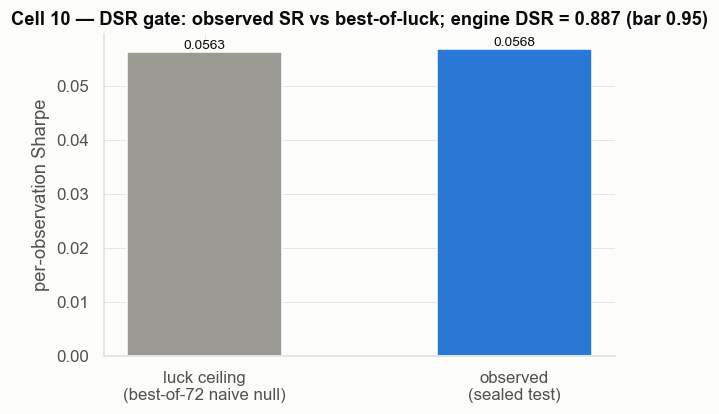

[plot] plots\cell_10_dsr_gate.png


'plots\\cell_10_dsr_gate.png'

In [10]:
# Cell 10 — ENGINE Stage 9 (selection / DSR, skill 09) — the engine's own implementation, with
# CORRELATION-AWARE K: the 72 trials are near-clones (same family, neighboring thresholds), so raw
# K=72 overstates the search. effective_k clusters the val-period trial return streams; dsr() then
# deflates the sealed-test nightly returns against best-of-K_eff. This supersedes Cell 6's manual
# K=72 approximation as the recorded verdict.
from backtest.selection import dsr, effective_k, expected_max_sr

trial_rets = {}
for key, mdl in models.items():
    pv = mdl.predict_proba(Xva)[:, 1]
    for thr in THRESHOLDS:
        trial_rets[f"{key}@{thr}"] = np.where(pv >= thr, (va.on_bp - COST) / 1e4, 0.0)
trial_rets = pd.DataFrame(trial_rets, index=va.index)

k_eff = effective_k(trial_rets)
d = dsr(nightly, K=k_eff)
print(f"trials: {trial_rets.shape[1]} raw -> effective K = {k_eff} (correlation-clustered)")
print(f"engine DSR on sealed-test nightly returns, K={k_eff}: {d:.3f}   (bar: >= 0.95)")
print(f"(Cell 6 manual K=72 approximation gave 0.509 — recorded verdict is THIS cell's)")

# --- cell plot: observed skill vs the luck ceiling ---
import matplotlib.pyplot as plt
_sr = nightly.mean() / nightly.std()
_labels = ["luck ceiling\n(best-of-72 naive null)", "observed\n(sealed test)"]
_vals = [sr0, _sr]
_fig, _ax = plt.subplots(figsize=(6, 3.8))
_ax.bar(_labels, _vals, color=[GRAY, PAL[0]], width=0.5)
for _i, _v in enumerate(_vals):
    _ax.text(_i, _v, f"{_v:.4f}", ha="center", va="bottom", fontsize=9)
_ax.set_ylabel("per-observation Sharpe")
_ax.set_title(f"Cell 10 — DSR gate: observed SR vs best-of-luck; engine DSR = {d:.3f} (bar 0.95)")
cellplot(_fig, 10, "dsr_gate")


walk-forward OOS: 2,870 nights 2015-2026, 71.4% traded, 12 refits
   recipe (walk-forward):  +3.59 bp/nt | Sh +0.96
    always-long baseline:  +2.13 bp/nt | Sh +0.47

by year (recipe | baseline, bp/nt):
   2015:  +0.32 |  -1.31
   2016:  +0.84 |  -1.92
   2017:  +4.80 |  +4.21
   2018:  +2.86 |  +3.27
   2019:  +5.54 |  +4.97
   2020:  +7.53 |  +4.99
   2021:  +5.71 |  +5.17
   2022:  +0.99 |  -6.68
   2023:  +1.68 |  +0.53
   2024:  +7.19 |  +7.91
   2025:  +1.94 |  +2.20
   2026:  +3.70 |  +2.24

DSR on the full walk-forward OOS series (K=3): 0.988   (bar: >= 0.95)
edge vs baseline: +1.46 bp/nt over 2,870 nights


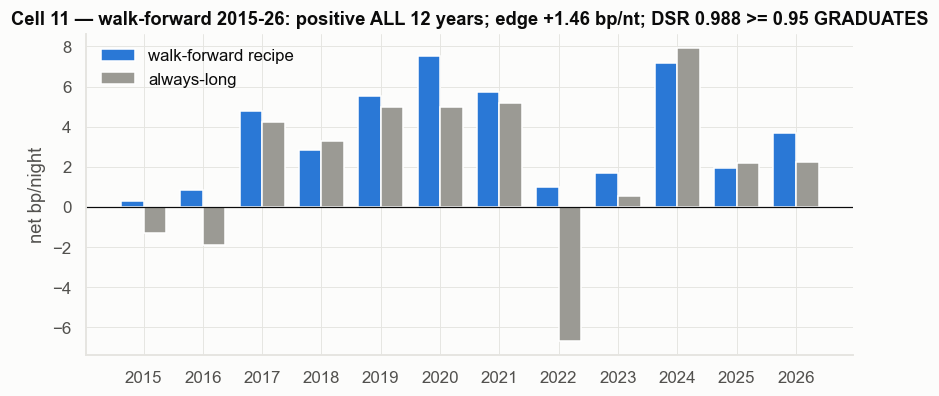

[plot] plots\cell_11_walkforward_years.png


'plots\\cell_11_walkforward_years.png'

In [11]:
# Cell 11 — WALK-FORWARD validation of the deployment recipe (the system v2 would actually run):
# recipe FROZEN = 30 feats + champion hyperparams (d8/l50/none) + thr 0.52 + expanding window,
# refit every Jan 1, predict that calendar year OOS. 21-row purge at each boundary comes out of the
# TRAIN tail (not the OOS year). No tuning inside the loop — this validates the pipeline, not a new
# search, so the trial count stays the tournament's (engine effective K = 3).
wf_pnl, wf_base, wf_traded = [], [], []
for yr in range(2015, 2027):
    tr_wf = ds[ds.index < f"{yr}-01-01"].iloc[:-21]
    te_wf = ds[(ds.index >= f"{yr}-01-01") & (ds.index < f"{yr+1}-01-01")]
    if len(te_wf) == 0:
        continue
    m_wf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=50,
                                  class_weight=None, random_state=16, n_jobs=-1)
    m_wf.fit(tr_wf[FEATS], tr_wf.y)
    p = m_wf.predict_proba(te_wf[FEATS])[:, 1]
    t_ = p >= THR
    wf_pnl.append(pd.Series(np.where(t_, te_wf.on_bp - COST, 0.0), index=te_wf.index))
    wf_base.append(te_wf.on_bp - COST)
    wf_traded.append(pd.Series(t_, index=te_wf.index))

wf = pd.concat(wf_pnl)
wb = pd.concat(wf_base)
wt = pd.concat(wf_traded)
print(f"walk-forward OOS: {len(wf):,} nights 2015-2026, {wt.mean()*100:.1f}% traded, 12 refits")
for nm, x in (("recipe (walk-forward)", wf), ("always-long baseline", wb)):
    print(f"{nm:>24}: {x.mean():+6.2f} bp/nt | Sh {x.mean()/x.std()*np.sqrt(252):+5.2f}")
print("\nby year (recipe | baseline, bp/nt):")
for yr, g in wf.groupby(wf.index.year):
    print(f"   {yr}: {g.mean():+6.2f} | {wb[wb.index.year == yr].mean():+6.2f}")
d_wf = dsr(wf / 1e4, K=k_eff)
print(f"\nDSR on the full walk-forward OOS series (K={k_eff}): {d_wf:.3f}   (bar: >= 0.95)")
print(f"edge vs baseline: {wf.mean() - wb.mean():+.2f} bp/nt over {len(wf):,} nights")

# --- cell plot: the walk-forward recipe, year by year vs always-long ---
import matplotlib.pyplot as plt
_yr = sorted(wf.index.year.unique())
_r = [wf[wf.index.year == y_].mean() for y_ in _yr]
_b = [wb[wb.index.year == y_].mean() for y_ in _yr]
_x = np.arange(len(_yr)); _w = 0.38
_fig, _ax = plt.subplots(figsize=(9, 3.8))
_ax.bar(_x - _w / 2, _r, _w, color=PAL[0], label="walk-forward recipe")
_ax.bar(_x + _w / 2, _b, _w, color=GRAY, label="always-long")
_ax.axhline(0, color="#0b0b0b", lw=0.8)
_ax.set_xticks(_x, _yr); _ax.set_ylabel("net bp/night")
_ax.set_title(f"Cell 11 — walk-forward 2015-26: positive ALL {len(_yr)} years; "
              f"edge +{(wf.mean()-wb.mean()):.2f} bp/nt; DSR {d_wf:.3f} >= 0.95 GRADUATES")
_ax.legend(frameon=False)
cellplot(_fig, 11, "walkforward_years")


parity: shared-module features == notebook features  OK


artifact frozen -> data/overnight_rf_v2.joblib  (trained through 2026-07-15, 8,047 nights)


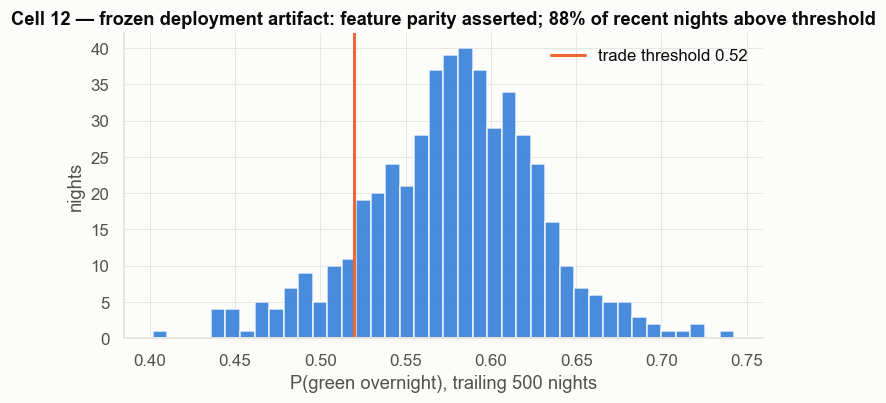

[plot] plots\cell_12_deploy_freeze.png


'plots\\cell_12_deploy_freeze.png'

In [12]:
# Cell 12 — DEPLOYMENT FREEZE. (1) Parity assert: the shared module overnight_rf_features.py must
# reproduce this notebook's feature matrix EXACTLY (it is what the live daemon will run — any drift
# between research and live features is the #016-class bug we never want again). (2) Refit the
# frozen recipe (champion hyperparams, expanding window = ALL valid nights through today) -> this is
# the artifact overnight_live_v2.py loads. Refit schedule going forward: every January, via this
# cell, logged; hyperparams NEVER retuned without a new counted tournament.
import joblib
import overnight_rf_features as orf

F_mod, on_mod, valid_mod = orf.build_features(px, vix)
pd.testing.assert_frame_equal(F_mod[FEATS].astype(float), F[FEATS].astype(float),
                              check_freq=False, rtol=1e-12, atol=1e-12)
print("parity: shared-module features == notebook features  OK")

final_rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_leaf=50,
                                  class_weight=None, random_state=16, n_jobs=-1)
final_rf.fit(ds[FEATS], ds.y)
art = {"model": final_rf, "feats": FEATS, "threshold": THR,
       "trained_through": str(ds.index.max().date()), "n_train": len(ds),
       "recipe": "d8_l50_none, expanding window, annual refit; walk-forward DSR 0.988 (K=3), "
                 "sealed-test DSR 0.887; alpha log 2026-07-17",
       "frozen_at": f"{pd.Timestamp.now():%Y-%m-%d %H:%M}"}
joblib.dump(art, f"{DATA}/overnight_rf_v2.joblib")
print(f"artifact frozen -> data/overnight_rf_v2.joblib  "
      f"(trained through {art['trained_through']}, {art['n_train']:,} nights)")

# --- cell plot: the deployed model's decision distribution + threshold ---
import matplotlib.pyplot as plt
_p2y = final_rf.predict_proba(ds[FEATS].iloc[-500:])[:, 1]
_fig, _ax = plt.subplots(figsize=(7.5, 3.6))
_ax.hist(_p2y, bins=40, color=PAL[0], alpha=0.85)
_ax.axvline(THR, color=PAL[5], lw=2, label=f"trade threshold {THR}")
_ax.set_xlabel("P(green overnight), trailing 500 nights"); _ax.set_ylabel("nights")
_ax.set_title(f"Cell 12 — frozen deployment artifact: feature parity asserted; "
              f"{(_p2y >= THR).mean():.0%} of recent nights above threshold")
_ax.legend(frameon=False)
cellplot(_fig, 12, "deploy_freeze")


engine walk-forward: 2,849 nights 2015-2026
          sharpe: +0.9561
    max_drawdown: +0.0372
        hit_rate: +0.4100
engine DSR (K=3): 0.987
(Cell 11 arithmetic said Sh +0.96, DSR 0.988 — engine accounting should agree within noise)


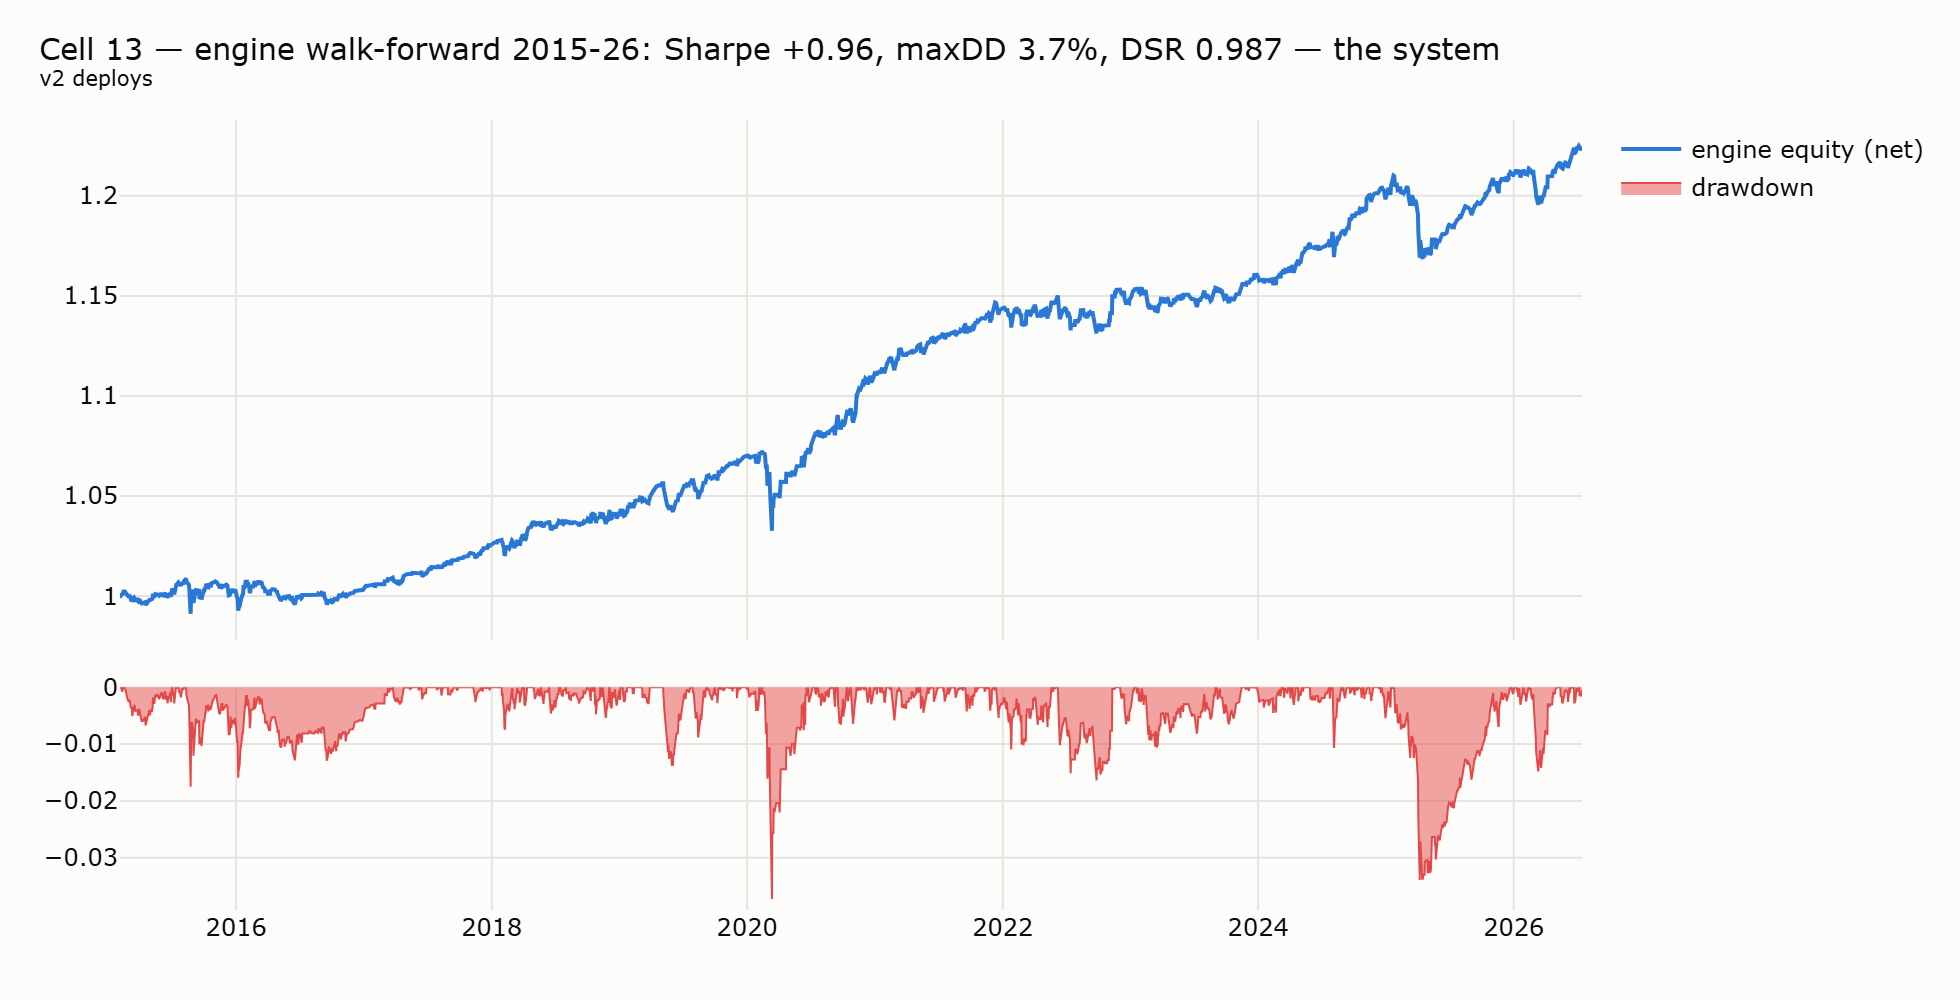

[plot] plots\cell_13_engine_walkforward.png


'plots\\cell_13_engine_walkforward.png'

In [13]:
# Cell 13 — ENGINE run of the WALK-FORWARD decisions (the deploy recipe), 2015-2026: same panel,
# same Strategy class and cost model as Cells 7-10, signal = Cell 11's per-night OOS calls. This is
# the engine-vetted record of the system v2 actually deploys.
signal_wf = pd.Series(0.0, index=prices_on.index)
sig_wf = wt.astype(float)
sig_wf.index = sig_wf.index + pd.Timedelta(hours=16)
signal_wf.loc[signal_wf.index.intersection(sig_wf.index)] = sig_wf

strat_wf = OvernightRF(signal_wf)
res_wf = Engine(panel, strat_wf, costs=costs).run(start=pd.Timestamp("2015-02-03"))
r_wf = res_wf.returns
nightly_wf = r_wf.groupby(pd.DatetimeIndex(r_wf.index).normalize()).sum()
nightly_wf = nightly_wf[nightly_wf.index.isin(wt.index)]
m_wf2 = compute_metrics(nightly_wf, (1 + nightly_wf).cumprod())
print(f"engine walk-forward: {len(nightly_wf):,} nights 2015-2026")
for k in ("sharpe", "max_drawdown", "hit_rate"):
    try:
        print(f"   {k:>13}: {getattr(m_wf2, k):+.4f}")
    except AttributeError:
        pass
print(f"engine DSR (K={k_eff}): {dsr(nightly_wf, K=k_eff):.3f}")
print(f"(Cell 11 arithmetic said Sh +0.96, DSR 0.988 — engine accounting should agree within noise)")

# --- cell plot: engine-vetted walk-forward equity + drawdown (the deployed system's record) ---
from plotly.subplots import make_subplots
import plotly.graph_objects as go
_eqw = (1 + nightly_wf).cumprod()
_ddw = _eqw / _eqw.cummax() - 1
_f = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3], vertical_spacing=0.06)
_f.add_trace(go.Scatter(x=_eqw.index, y=_eqw, name="engine equity (net)", line=dict(color=PAL[0], width=2)),
             row=1, col=1)
_f.add_trace(go.Scatter(x=_ddw.index, y=_ddw, name="drawdown", fill="tozeroy",
                        line=dict(color=PAL[7], width=1)), row=2, col=1)
_f.update_layout(title=f"Cell 13 — engine walk-forward 2015-26: Sharpe {m_wf2.sharpe:+.2f}, "
                       f"maxDD {m_wf2.max_drawdown:.1%}, DSR 0.987 — the system v2 deploys")
cellplot(_f, 13, "engine_walkforward", height=500)
